## Object Detection + VLMs(Visual Language Models)

⸻

#### Setup 

In [1]:
# module import
# basic module
import os, sys, copy

# data handling / io
import numpy as np
import pandas as pd
import json, base64

# image handling
from PIL import Image, ImageDraw, ImageFont
import cv2 # 박스 그리기/ 좌표 변환 
import torch

# LLM
from openai import OpenAI
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from PIL import Image, ImageDraw, ImageFont

# Utils
from tqdm import tqdm
import time, argparse, logging, uuid
from dotenv import load_dotenv

"""
# deep learnign & detection 
from groundingdino.models import build_model
from groundingdino.util.slconfig import SLConfig
from groundingdino.util.utils import clean_state_dict
from groundingdino.util.inference import load_model, predict, annotate
"""

# 2. co-utils: 경로/출력 폴더 생성
input_image_dir = "notebook/data_notebook"
output_image_dir = "notebook/output_notebook"

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def get_project_path(*paths):
    project_root = os.getcwd()    # or use a specific absolute path if needed
    return os.path.join(project_root, *paths)


# 시드 고정

c:\Users\KIST\agentic-object-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Utils
#  프로젝트 루트 탐색
def find_project_root(marker_filename=".project-root"):
    current_dir = os.path.abspath(os.getcwd())
    while True:
        if os.path.isfile(os.path.join(current_dir, marker_filename)):
            return current_dir
        parent_dir = os.path.dirname(current_dir)
        if parent_dir == current_dir:
            raise FileNotFoundError(f"Could not find {marker_filename} in any parent directory.")
        current_dir = parent_dir

# b64 encoder: jpg image -> base64 string / VLM API
def encode_image_to_base64(img_path):
    try: 
        with open(img_path, "rb") as image_file:
            return base64.b64encode(image_file.read()).decode("utf-8")
    except Exception as e:
        print(f"Error encoding image.: {e}")
        return None

In [ ]:
# example: base64 encoding
input_img_path = os.path.join(os.getcwd(), "data_notebook", "i_0.jpg")
output_img_path = os.path.join(os.getcwd(), "output_notebook", "o_0.jpg")

b64str = encode_image_to_base64(input_img_path) 
print("인코딩 문자열의 앞 50자: ")
print(b64str[:50]) 

인코딩 문자열의 앞 50자: 
/9j/4AAQSkZJRgABAQEBLAEsAAD/7Sm+UGhvdG9zaG9wIDMuMA


In [ ]:
# example
# 로그 파일 설정 (스크립트와 같은 폴더에 my_exp.log 생성)
logging.basicConfig(
    filename='my_exp.log',
    level=logging.INFO,
    format='%(asctime)s:%(levelname)s:%(message)s'
)

# 임시로 저장할 결과 폴더 생성
output_dir = "results"
os.makedirs(output_dir, exist_ok=True)

# 진행바와 함께 파일 생성 및 로그 남기기 예시
for idx in tqdm(range(5), desc="Processing"):
    unique_name = f"result_{uuid.uuid4()}.txt"
    file_path = os.path.join(output_dir, unique_name)

    # 더미 데이터 파일 생성
    with open(file_path, 'w') as f:
        f.write(f"이 파일은 {idx}번째로 생성된 임시 파일입니다.\n")

    logging.info(f"{idx}번째 작업, 결과 파일: {file_path}")
    time.sleep(1)  # 시간 지연(실제 작업 대체용)

logging.info("모든 작업 완료")
print("실행이 끝났습니다. 'my_exp.log'에서 로그를 확인하세요.")

Processing: 100%|██████████| 5/5 [00:05<00:00,  1.00s/it]

실행이 끝났습니다. 'my_exp.log'에서 로그를 확인하세요.


#### Config

In [20]:
# === Config ===

# 1. 입력 이미지 경로, 출력 디렉토리 지정
input_img_path = os.path.join(os.getcwd(), "data_notebook", "i_0.jpg")
output_img_path = os.path.join(os.getcwd(), "output_notebook", "o_0.jpg")


# 2. detectcor / device/ threshold / 최대 박스 수
MODEL_TYPES = {
    "owlvit": "google/owlvit-base-patch32",
    "grounding_dino": "IDEA-Research/grounding-dino-tiny",} # 모델 로드
DEFAULT_MODEL_TYPE = "grounding_dino"
MODEL_ID = MODEL_TYPES[DEFAULT_MODEL_TYPE]

INV_MODEL_TYPES = {v:k for k,v in MODEL_TYPES.items()} # 모델 별칭 딕셔너리

# device config
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# detection config
CONFIDENCE_THRESHOLD = 0.2
MAX_BOXES = 20


# 3. VLM 모델명(개념 추출: gpt-4o, 질의 비평: o1, 최종 검증: gpt-4o), 토큰/온도 등
CONCEPT_EXTRACTION_VLM = "gpt-4.1"  # 초기 개념 추출
CRITIQUE_VLM = "gpt-4o"            # 쿼리 비평 및 개선
VALIDATION_VLM = "gpt-4.1"         # 최종 검증


# 4. 숫자 라벨/ 패딩 옵션, 폰트/두께, 색
COLOR_PALETTE = [
    "red", "blue", "green", "purple", "orange", 
    "cyan", "magenta", "yellow", "brown", "pink"]
FONT_PATH = "fonts/arial.ttf"

IMAGE_EXTENSIONS = ("jpg", "jpeg", "png")
DRAW_FONT_SIZE = 22
DRAW_LABEL_LANG = "en"      # 'en' or 'ko'

LABEL_BOX_COLOR = "red"
LABEL_FONT_SIZE = 18
LABEL_LINE_WIDTH = 3

# 5. chatGPT API key
project_root = find_project_root()
dotenv_path = os.path.join(project_root, ".env")
load_dotenv(dotenv_path)



True

#### VLM Tool

In [ ]:
# === VLM Tool ===
class VLMTool:
    def __init__(self, api_key):
        self.client = OpenAI(api_key=api_key)

In [ ]:
# 1. chat completion: VLM API 요청, 응답 저장
def model_response(self, messages, model="gpt-4.1", temperature=0.1, max_tokens=1000, response_format=None):
    try: 
        # 텍스트 생성 요청
        if model in ["gpt-4.1", "gpt-4o"]:
            response = self.client.chat.completions.create(
                model=model,
                messages=messages,
                max_completion_tokens=max_tokens,
                response_format=response_format if response_format else {"type": "text"},
                temperature=temperature
            ) # open ai class method
        else: 
            raise NotImplementedError("This model is not supported")
        
        # 응답 추출
        return response.choices[0].message.content # open ai 응답 메시지 리스트 중 첫 번쨰 답변만

    except Exception as e:
        print(f"Error calling LLM: {e}")
        return None
VLMTool.model_response = model_response

# 2. extract objects from request: 탐지 객체 목록 문자열 리스트로 추출
def extract_objects_from_request(self, image_path, user_text, model="gpt-4.1"):
    try:
        base64_image = encode_image(image_path)
        if not base64_image:
            return None

        # prompt
        prompt = (
            "You are an AI assistant that identifies the primary subject for an object detection task from a user's request. "
            "Your goal is to extract ONLY the main object(s) the user wants to find, including their specific attributes like color or state. "
            "Pay close attention to the grammar. If an object is mentioned as part of a location or relationship (e.g., 'the cat on the chair', 'tomatoes hidden by leaves'), do NOT extract the contextual object (like 'chair' or 'leaves'). Extract only the primary subject of the request."
            "If the user asks to find 'all objects' or makes a similarly broad request, you must carefully analyze the provided image and return a comma-separated list of all distinct objects you can identify. For example, if the image shows tomatoes on a vine, a good response would be 'tomatoes, tomato vine, leaves'."
            "Respond ONLY with a comma-separated list of the primary objects and NOTHING ELSE."
            "For example, for 'Find the red tomatoes hidden by leaves', you should respond with 'red tomatoes'."
            "For 'Show me the dog on the bed', you should respond with 'dog'."
        )

        # messages: multi modal
        messages = [
            {"role": "system", "content": prompt},
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": user_text},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{base64_image}",
                            "detail": "high"
                        }
                    }
                ]
            }
        ]
        
        # 결과
        result = self.model_response(messages, model=model)

        # 리스트 생성
        if result:
            detected_objects = [obj.strip().lower() for obj in result.split(",") if obj.strip()]
            return detected_objects
    
    except Exception as e:
        print(f"Error extracting objects from request: {e}")
        return None
VLMTool.extract_objects_from_request = extract_objects_from_request

VLMTool example

Image


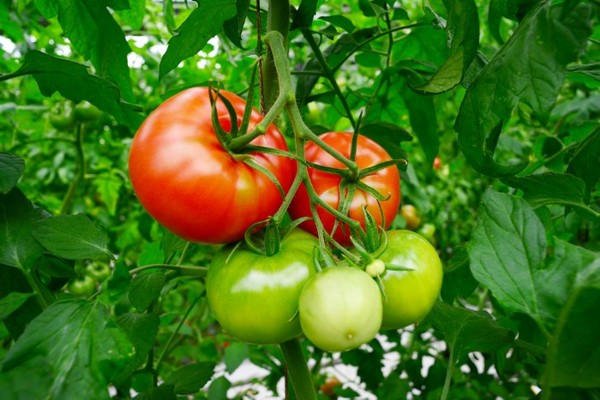

In [29]:
print("Image")
display(Image.open(input_img_path))

In [ ]:
# fig & initialize VLM Tool
api_key = os.getenv("OPENAI_API_KEY")
vlm_tool = VLMTool(api_key=api_key)

# example 1: 모든 객체 탐지
image_path_1 = input_img_path
user_request_1 = "Find all objects in this picture."

img_b64 = encode_image_to_base64(image_path_1)
message1 = [
    {
        "role": "system", 
        "content": "You are an AI assistant that identifies the primary subject for an object detection task from a user's request."},
    {  
        "role": "user", 
        "content": [
            {"type": "text", "text": user_request_1}, 
            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{img_b64}", "detail": "high"}}]}
]

result = vlm_tool.model_response(message1)
object_1 = vlm_tool.extract_objects_from_request(image_path_1, user_request_1)
print("Message1: ", f"{result}")
print("\n")
print("User Request1: ", f"{user_request_1}")
print("Detected Object1: ", f"{object_1}")
print("\n")

# example 2: 토마토의 색 탐지
image_path_2 = input_img_path
user_request_2 = "Find tomatoes's color."
object_2 = vlm_tool.extract_objects_from_request(image_path_2, user_request_2)
print("User Request2: ", f"{user_request_2}")
print("Detected  Object2: ", f"{object_2}")

Message1:  The primary objects in this picture are:

1. Tomatoes (at different stages of ripeness: red, green, and light green)
2. Tomato plant stems
3. Tomato plant leaves

The main focus is on the cluster of tomatoes growing on the vine.


User Request1:  Find all objects in this picture.
Detected Object1:  ['red tomatoes', 'green tomatoes', 'tomato vine', 'leaves']


User Request2:  Find tomatoes's color.
Detected Object2:  ['red', 'green', 'light green']


#### Detector

In [ ]:
class ObjectDetectionTool:
    def __init__(self, model_id, device, vlm_tool, threshold=0.2, concept_detection_model="gpt-4.1", initial_critique_model="gpt-4o", final_critique_model="gpt-4.1"):
        self.model_id = model_id # owlvit or groungding dino
        self.processor = AutoProcessor.from_pretrained(model_id) # 모델 전처리, 후처리 - 입력 포맷
        self.model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device) # 제로샷 추론 모델 
        self.device = device 
        self.vlm_tool = vlm_tool    
        self.threshold = threshold
        self.initial_critique_model = initial_critique_model
        self.final_critique_model = final_critique_model

        # store bounding boxes for potential usage later (e.g., for SAM).
        self.last_detection_bboxes = []
        self.last_filtered_objects = []

In [ ]:
def _run_detector(self, image_path, query_list):
    """
    input: image, object query(label)
    output: initial_detection[{bbox, score, label}]
    """
    # === 모델에 맞게 쿼리 수정 === 
    # grounding_dino: "cat. dog. person." 마침표로 구분된 문자열
    if INV_MODEL_TYPES[self.model_id] == "grounding_dino":
        formatted_queries = " ".join([f"{q}." for q in list(query_list)])
    # owl-vit: "An image of {q}", 텍스트 프롬프트 
    elif INV_MODEL_TYPES[self.model_id] == "owlvit":
        formatted_queries = [f"An image of {q}" for q in query_list] 
    else:
        raise NotImplementedError("Model not supported")
    
    # image load: PIL Image, rgb format
    img = Image.open(image_path).convert("RGB") 

    # === input preprocess ===
    inputs = self.processor(
        text=formatted_queries,
        images=img,
        return_tensors="pt", # pytorch tensor
        padding=True,
        truncation=True
    ).to(self.device) # model input format

    # === model inferences === 
    self. model.eval()
    with torch.no_grad():
        outputs = self.model(**inputs)

    # === model input & output debugging ===
    print("===Input===")
    print("Formatted queries:", formatted_queries) 
    print("Image size:", img.size) # (width, height)
    print("pixel values:", inputs["pixel_values"].shape)
    print("Inputs keys:", inputs.keys())
    # input_ids: query -> tokenize -> index(BERT format)
    # attention_mask: padding 0, valid token 1 -> masked vector
    # pixel_values: tensor [batch, channel, height, width]
    for k, v in inputs.items():
        print(f"{k}: shape={v.shape}, dtype={v.dtype}")
    
    print("===Output===")
    print("Model outputs:", outputs)

    # === Post-procss bounding boxes === 
    # 
    if INV_MODEL_TYPES[self.model_id] == "grounding_dino":
        results = self.processor.post_process_grounded_object_detection
        
    elif INV_MODEL_TYPES[self.model_id] ==  "owlvit": 
        
    else:
        raise NotImplementedError("Model not supported")

ObjectDetectionTool._run_detector = _run_detector
    

In [ ]:
"""AutoProcessor & AutoModelForZeroShotObjectDetection 이미지 텍스트쿼리 처리 input, output""" 

# 예시 더미 VLM 도구
class DummyVLMTool:
    def chat_completion(self, messages, model, **kwargs):
        return "dummy"

# 모델 ID 지정
model_id = MODEL_TYPES["owlvit"]  # 또는 MODEL_TYPES["grounding_dino"]

# 인스턴스 생성 시 필수 인자 3개 전달
dummy_vlm = DummyVLMTool()
detector = ObjectDetectionTool(
    model_id=model_id,
    device="cpu",         
    vlm_tool=dummy_vlm
)

# _run_detector 호출
image_path = "/Users/gohhyeonjin/Desktop/agentic-object-detection-main/notebook/input/img_0.jpg"
query_list = ["tomato", "leaf", "stem"]
outputs = detector._run_detector(image_path, query_list)

=== 결과 해석 ===

* Model: Owl ViT 

* Inputs keys: KeysView({'input_ids', 'attention_mask', 'pixel_values'})

* input_ids
    * query -> tokenize -> index(BERT format)
    * 각 행이 하나의 쿼리 문장
    * 토크나이저가 문장을 단어 단위로 분해한 후 사전에 매칭한 token
    * ```python
        'input_ids': 
            tensor([
                [49406,   550,  2867,   539,  9867, 49407],  # An image of tomato
                [49406,   550,  2867,   539,  7232, 49407],  # An image of leaf
                [49406,   550,  2867,   539,  6761, 49407]   # An image of stem
            ])
        ```

* attention_mask
    * padding 0, valid token 1 -> masked vector
    * ```python
        'attention_mask':
            tensor([
                [1, 1, 1, 1, 1, 1], # An image of tomato
                [1, 1, 1, 1, 1, 1], # An image of leaf
                [1, 1, 1, 1, 1, 1] # An image of stem
            ])
        ```

* pixel_values
    * VLM에 입력되는 이미지 데이터 - 전처리되어 모델이 학습한 형식에 맞춘 텐서
    * tensor [batch, channel, height, width]: ([1, 3, 768, 768])
    * 한 장의 RGB 이미지를 768*768 크기로 바꿔서 입력으로 사용
    * 이미지의 픽셀을 [-1, 1] 범위로 정규화
    * ```python
        'pixel_values': tensor([[[[
            -0.9164, -0.9164, -0.9164,  ..., -1.2083, -1.1791, -1.1499],
            [-0.9018, -0.9018, -0.9018,  ..., -1.1937, -1.1791, -1.1645],
            [-0.9164, -0.9018, -0.8872,  ..., -1.2083, -1.2083, -1.2083],
            ...,
            [-1.3981, -1.3689, -1.3543,  ..., -1.2959, -1.2959, -1.2959],
            [-1.3981, -1.3981, -1.3689,  ..., -1.2959, -1.2959, -1.3105],
            [-1.3543, -1.3543, -1.3543,  ..., -1.2813, -1.2959, -1.3251]
        ]]])
        ```

* output 
    * zero-shot object detection을 수행한 결과
    * 다양한 필드의 텐서를 포함한 구조체 

#### Initial detection

In [ ]:
# === 1차 detection === 
# 원본 이미지 + 개념 리스트 -> no_grad 추론 -> conf/iou 필터 -> 픽셀 좌표 변환 

#### Annotation

In [ ]:
# === Numbered Batching === 
# 흰색 테두리로 이미지 패딩, 각 박스에 번호 + 화살표 주석을 반영

#### Critique & Refine

In [ ]:
# === Critique/Refine ===
# “너무 구체/오분류 라벨→상위 개념 일반화”를 요청

#### Second detection

In [ ]:
# === 2차 detection ===


#### Validation

In [ ]:
# === 최종 validation ===
# 최종 검증 모델(gpt-4o)에 유효한 객체 번호 제시 -> 최종 박스 좌표 출력

#### Final output

In [ ]:
# 결과 정리 

In [ ]:
# 실험 체크리스트 
# 개념 추출이 “명시 vs 나열” 모두 잘 동작하는지
# 1차 탐지 → 비평 → 2차 탐지가 있을 때 성능이 개선되는지
# 숫자 배칭 한 번만으로 모든 박스를 검증 가능(박스별 크롭을 다수 요청하는 것보다 효율적)함을 확인